# 1. Carga y exploración inicial de los datos

En esta sección se carga la base de datos y se realiza una exploración inicial para conocer su estructura, tipos de variables, valores faltantes y principales características estadísticas.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Carga la base de datos en un DataFrame
df = pd.read_csv("base_ML.csv")

# Muestra las primeras filas
df.head()

,cliente_id,periodo,cliente_edad,web_visitas_mes,publicidad_inversion,comportamiento_usuario,tipo_visitante,producto_categoria,canal_compra,compras_categoria,valor_mensual_ventas,compra_actual
0,C0001,2025-01,29.0,6,109464.33,Web,Nuevo,Sin compra,Sin compra,0,0.0,0
1,C0001,2025-02,29.0,4,90584.88,Web,Nuevo,Sin compra,Sin compra,0,0.0,0
2,C0001,2025-03,29.0,6,123795.00,Web,Nuevo,Sin compra,Sin compra,0,0.0,0
3,C0001,2025-04,29.0,6,63583.47,Web,Nuevo,Sin compra,Sin compra,0,0.0,0
4,C0001,2025-05,29.0,9,137607.30,Aplicacion,Recurrente,Belleza,Aplicacion,1,468000.0,1


In [4]:
# Obtiene el número de filas y columnas de la base
df.shape

(6000, 12)

In [5]:
# Muestra los tipos de datos y los valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cliente_id              6000 non-null   str    
 1   periodo                 6000 non-null   str    
 2   cliente_edad            5842 non-null   float64
 3   web_visitas_mes         6000 non-null   int64  
 4   publicidad_inversion    5791 non-null   float64
 5   comportamiento_usuario  6000 non-null   str    
 6   tipo_visitante          6000 non-null   str    
 7   producto_categoria      6000 non-null   str    
 8   canal_compra            6000 non-null   str    
 9   compras_categoria       6000 non-null   int64  
 10  valor_mensual_ventas    6000 non-null   float64
 11  compra_actual           6000 non-null   int64  
dtypes: float64(3), int64(3), str(6)
memory usage: 562.6 KB


In [6]:
# Cuenta los valores faltantes por variable
df.isnull().sum()

cliente_id                  0
periodo                     0
cliente_edad              158
web_visitas_mes             0
publicidad_inversion      209
comportamiento_usuario      0
tipo_visitante              0
producto_categoria          0
canal_compra                0
compras_categoria           0
valor_mensual_ventas        0
compra_actual               0
dtype: int64

In [7]:
# Genera estadísticas descriptivas de las variables numéricas
df.describe()

,cliente_edad,web_visitas_mes,publicidad_inversion,compras_categoria,valor_mensual_ventas,compra_actual
count,5842.000000,6000.000000,5791.000000,6000.000000,6.000000e+03,6000.000000
mean,43.487847,9.148500,106154.656211,0.995333,2.966367e+05,0.593333
std,14.875110,3.943903,35474.549570,1.055382,3.238034e+05,0.491253
min,18.000000,0.000000,5000.000000,0.000000,0.000000e+00,0.000000
25%,32.000000,6.000000,81693.810000,0.000000,0.000000e+00,0.000000
50%,43.000000,9.000000,105564.110000,1.000000,2.750000e+05,1.000000
75%,55.000000,11.000000,130500.105000,2.000000,4.630000e+05,1.000000
max,70.000000,27.000000,220000.000000,4.000000,2.254000e+06,1.000000


In [8]:
# Muestra las categorías y su frecuencia en las variables categóricas
for columna in ["comportamiento_usuario", "tipo_visitante",
                "producto_categoria", "canal_compra"]:
    print(f"\n{columna}")
    print(df[columna].value_counts())


comportamiento_usuario
comportamiento_usuario
Web           2546
Aplicacion    2278
Ambos         1176
Name: count, dtype: int64

tipo_visitante
tipo_visitante
Recurrente    5201
Nuevo          799
Name: count, dtype: int64

producto_categoria
producto_categoria
Sin compra     2440
Electronica     797
Ropa            783
Hogar           729
Deportes        631
Belleza         620
Name: count, dtype: int64

canal_compra
canal_compra
Sin compra    2440
Aplicacion    1833
Web           1727
Name: count, dtype: int64


In [9]:
# Cuenta los registros completamente duplicados
df.duplicated().sum()

np.int64(0)

In [10]:
# Cuenta los clientes y periodos diferentes registrados
print("Clientes únicos:", df["cliente_id"].nunique())
print("Periodos únicos:", df["periodo"].nunique())

Clientes únicos: 500
Periodos únicos: 12


# 2. Preparación y limpieza de los datos

En esta sección se preparan los datos para su utilización en los modelos de Machine Learning. Se realizará el tratamiento de los valores faltantes, la selección de las variables que serán utilizadas como predictoras y la transformación de las variables categóricas.

In [11]:
# Cuenta los valores faltantes que serán tratados durante el preprocesamiento
print("Total de valores faltantes:", df.isnull().sum().sum())

Total de valores faltantes: 367


In [12]:
# Ordena los registros por cliente y periodo
df = df.sort_values(["cliente_id", "periodo"]).reset_index(drop=True)

# Obtiene el tipo de visitante registrado en el periodo anterior
df["tipo_visitante_lag"] = df.groupby("cliente_id")["tipo_visitante"].shift(1)

# Identifica los primeros registros de cada cliente sin historial previo
df["tipo_visitante_lag"] = df["tipo_visitante_lag"].fillna("Sin historial")

# Calcula la tasa de compra según el tipo de visitante del periodo anterior
df.groupby("tipo_visitante_lag")["compra_actual"].mean().round(3)

tipo_visitante_lag
Nuevo            0.392
Recurrente       0.651
Sin historial    0.372
Name: compra_actual, dtype: float64

In [13]:
# Define las variables objetivo de los modelos
objetivo_regresion = "valor_mensual_ventas"
objetivo_clasificacion = "compra_actual"

# Define las variables disponibles antes del resultado que se desea predecir
variables_predictoras = [
    "cliente_edad",
    "web_visitas_mes",
    "publicidad_inversion",
    "comportamiento_usuario",
    "tipo_visitante_lag"
]

In [14]:
# Define las variables numéricas y categóricas que serán utilizadas por los modelos
variables_numericas = [
    "cliente_edad",
    "web_visitas_mes",
    "publicidad_inversion"
]

variables_categoricas = [
    "comportamiento_usuario",
    "tipo_visitante_lag"
]

print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)

Variables numéricas: ['cliente_edad', 'web_visitas_mes', 'publicidad_inversion']
Variables categóricas: ['comportamiento_usuario', 'tipo_visitante_lag']


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [16]:
# Define el tratamiento de las variables numéricas
transformacion_numerica = Pipeline([
    ("imputacion", SimpleImputer(strategy="median")),
    ("escalamiento", StandardScaler())
])

# Define el tratamiento de las variables categóricas
transformacion_categorica = Pipeline([
    ("codificacion", OneHotEncoder(handle_unknown="ignore"))
])

# Combina las transformaciones para los diferentes tipos de variables
preprocesamiento = ColumnTransformer([
    ("numericas", transformacion_numerica, variables_numericas),
    ("categoricas", transformacion_categorica, variables_categoricas)
])

In [17]:
from sklearn.model_selection import train_test_split

# Selecciona las variables predictoras para los modelos de clasificación
X_clasificacion = df[variables_predictoras]

# Selecciona la variable objetivo de clasificación
y_clasificacion = df[objetivo_clasificacion]

# Divide los datos en entrenamiento y prueba
X_train_clas, X_test_clas, y_train_clas, y_test_clas = train_test_split(
    X_clasificacion,
    y_clasificacion,
    test_size=0.2,
    random_state=42,
    stratify=y_clasificacion
)

In [18]:
# Se entrena solo con los clientes-mes que SÍ compraron: predice
# "dado que el cliente compra, ¿cuánto gasta?" en vez de mezclar
# compradores y no-compradores (que son ceros estructurales)
df_compradores = df[df["compra_actual"] == 1]

# Selecciona las variables predictoras para la predicción de ventas
X_regresion = df_compradores[variables_predictoras]

# Selecciona la variable objetivo de regresión
y_regresion = df_compradores[objetivo_regresion]

# Divide los datos en entrenamiento y prueba
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regresion,
    y_regresion,
    test_size=0.2,
    random_state=42
)

In [19]:
# Muestra el tamaño de los conjuntos de entrenamiento y prueba
print("Clasificación:")
print("Entrenamiento:", X_train_clas.shape)
print("Prueba:", X_test_clas.shape)

print("\nRegresión:")
print("Entrenamiento:", X_train_reg.shape)
print("Prueba:", X_test_reg.shape)

Clasificación:
Entrenamiento: (4800, 5)
Prueba: (1200, 5)

Regresión:
Entrenamiento: (2848, 5)
Prueba: (712, 5)


# 3. Regresión Lineal

En esta sección se construye un modelo de Regresión Lineal para predecir el valor mensual de las ventas a partir de las características disponibles de los clientes.

In [20]:
from sklearn.linear_model import LinearRegression

# Combina el preprocesamiento con el modelo de Regresión Lineal
modelo_regresion = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("modelo", LinearRegression())
])

In [21]:
# Entrena el modelo utilizando los datos de entrenamiento
modelo_regresion.fit(X_train_reg, y_train_reg)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['cliente_edad','web_visitas_mes','publicidad_inversion', 'comportamiento_usuario','tipo_visitante_lag']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be au

In [22]:
# Genera las predicciones sobre los datos de prueba
y_pred_reg = modelo_regresion.predict(X_test_reg)

In [23]:
# Muestra algunos valores reales y sus respectivas predicciones
comparacion = pd.DataFrame({
    "Valor real": y_test_reg.values,
    "Valor predicho": y_pred_reg
})

comparacion.head(10)

,Valor real,Valor predicho
0,431000.0,638358.656768
1,318000.0,481596.914879
2,460000.0,673835.485587
3,366000.0,630505.712791
4,372000.0,487223.870249
5,411000.0,512580.337586
6,1146000.0,416885.102108
7,786000.0,395679.367348
8,260000.0,400181.404885
9,257000.0,461912.161127


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calcula las métricas de evaluación del modelo
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 179304.1109858399
MSE: 59445055154.463264
RMSE: 243813.56638723626
R²: 0.23658381737667755


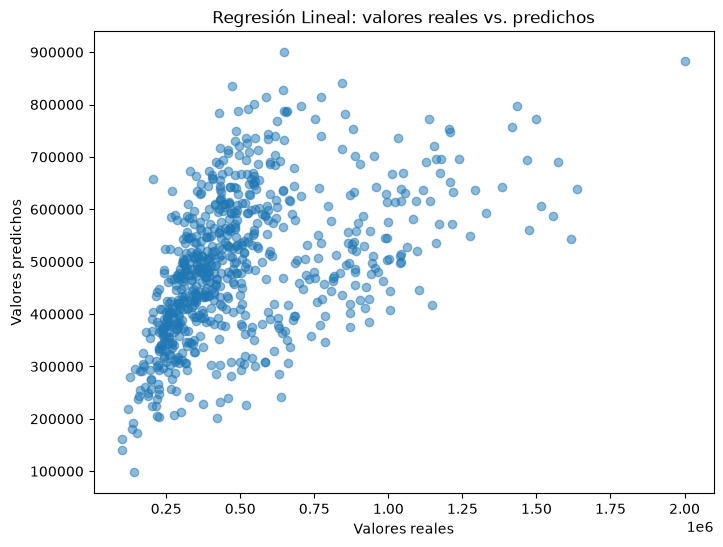

In [25]:
# Compara visualmente los valores reales con las predicciones
plt.figure(figsize=(8, 6))

plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Regresión Lineal: valores reales vs. predichos")

plt.show()

# 4. Regresión Logística

En esta sección se construye un modelo de Regresión Logística para predecir si un cliente realizará una compra o no a partir de sus características.

In [26]:
from sklearn.linear_model import LogisticRegression

# Combina el preprocesamiento con el modelo de Regresión Logística
modelo_logistico = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("modelo", LogisticRegression(max_iter=1000))
])

In [27]:
# Entrena el modelo utilizando los datos de entrenamiento
modelo_logistico.fit(X_train_clas, y_train_clas)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['cliente_edad','web_visitas_mes','publicidad_inversion', 'comportamiento_usuario','tipo_visitante_lag']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [28]:
# Genera las predicciones sobre los datos de prueba
y_pred_log = modelo_logistico.predict(X_test_clas)

In [29]:
# Muestra algunos valores reales y sus respectivas predicciones
comparacion_log = pd.DataFrame({
    "Valor real": y_test_clas.values,
    "Valor predicho": y_pred_log
})

comparacion_log.head(10)

,Valor real,Valor predicho
0,0,0
1,0,0
2,1,1
3,1,1
4,1,1
5,1,1
6,0,1
7,1,1
8,0,1
9,1,1


In [30]:
# Obtiene la probabilidad estimada de compra
probabilidades_compra = modelo_logistico.predict_proba(X_test_clas)[:, 1]

probabilidades_compra[:10]

array([0.41358129, 0.46730334, 0.61846925, 0.51987072, 0.8742548 ,
       0.68298618, 0.80110998, 0.69215588, 0.63341717, 0.75638304])

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Calcula las métricas de evaluación del modelo
accuracy = accuracy_score(y_test_clas, y_pred_log)
precision = precision_score(y_test_clas, y_pred_log)
recall = recall_score(y_test_clas, y_pred_log)
f1 = f1_score(y_test_clas, y_pred_log)
roc_auc = roc_auc_score(y_test_clas, probabilidades_compra)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)

Accuracy: 0.6366666666666667
Precision: 0.6490280777537797
Recall: 0.8441011235955056
F1-score: 0.7338217338217338
ROC-AUC: 0.6591510867563087


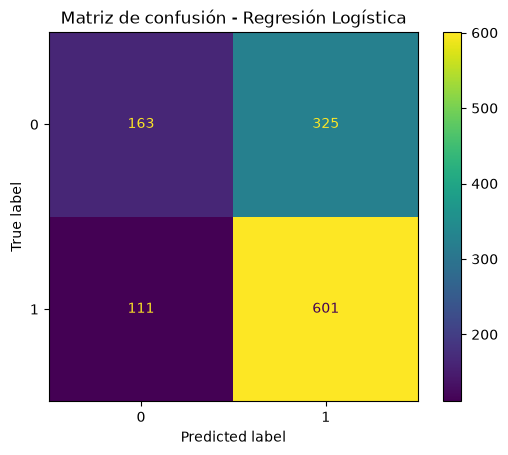

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calcula la matriz de confusión
matriz_confusion = confusion_matrix(y_test_clas, y_pred_log)

# Muestra la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion)
disp.plot()

plt.title("Matriz de confusión - Regresión Logística")
plt.show()

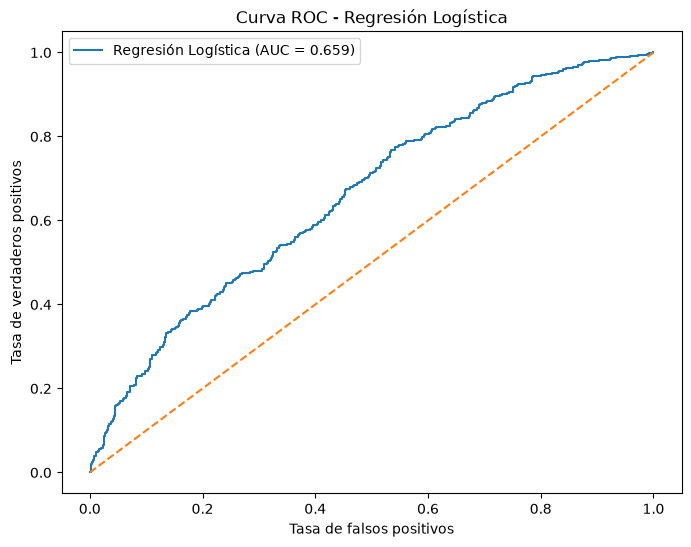

In [33]:
from sklearn.metrics import roc_curve

# Calcula los valores necesarios para construir la curva ROC
fpr, tpr, umbrales = roc_curve(y_test_clas, probabilidades_compra)

# Grafica la curva ROC
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Regresión Logística (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Regresión Logística")
plt.legend()

plt.show()

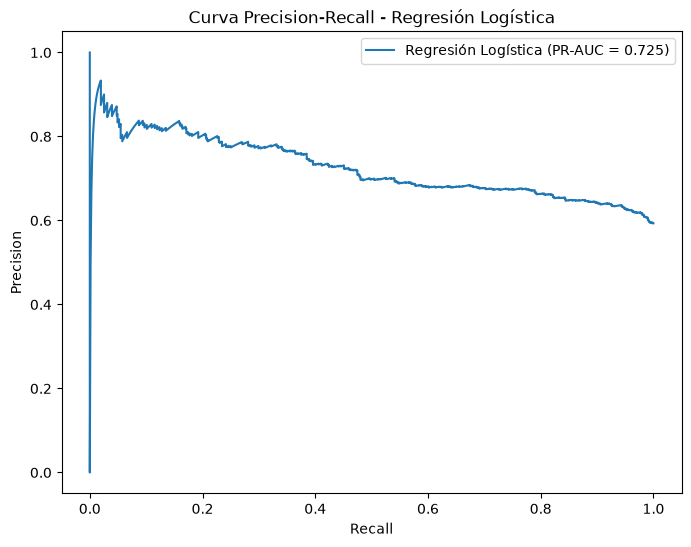

In [62]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calcula los valores necesarios para construir la curva Precision-Recall
precision_curva, recall_curva, umbrales_pr = precision_recall_curve(y_test_clas, probabilidades_compra)

# Calcula el area bajo la curva Precision-Recall
pr_auc = average_precision_score(y_test_clas, probabilidades_compra)

# Grafica la curva Precision-Recall
plt.figure(figsize=(8, 6))

plt.plot(recall_curva, precision_curva, label=f"Regresión Logística (PR-AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Regresión Logística")
plt.legend()

plt.show()

In [34]:
# Evalúa el comportamiento del modelo con diferentes umbrales
umbrales_prueba = [0.3, 0.4, 0.5, 0.6, 0.7]

for umbral in umbrales_prueba:
    predicciones_umbral = (probabilidades_compra >= umbral).astype(int)

    precision_umbral = precision_score(y_test_clas, predicciones_umbral)
    recall_umbral = recall_score(y_test_clas, predicciones_umbral)
    f1_umbral = f1_score(y_test_clas, predicciones_umbral)

    print(f"Umbral: {umbral}")
    print(f"Precision: {precision_umbral:.3f}")
    print(f"Recall: {recall_umbral:.3f}")
    print(f"F1-score: {f1_umbral:.3f}")
    print()

Umbral: 0.3
Precision: 0.610
Recall: 0.983
F1-score: 0.753

Umbral: 0.4
Precision: 0.636
Recall: 0.942
F1-score: 0.759

Umbral: 0.5
Precision: 0.649
Recall: 0.844
F1-score: 0.734

Umbral: 0.6
Precision: 0.679
Recall: 0.607
F1-score: 0.641

Umbral: 0.7
Precision: 0.779
Recall: 0.331
F1-score: 0.465



# 5. K-Nearest Neighbors (K-NN)

En esta sección se construye un modelo K-Nearest Neighbors para clasificar a los clientes según la similitud de sus características con otros registros históricos.

In [35]:
from sklearn.neighbors import KNeighborsClassifier

# Combina el preprocesamiento con el modelo K-NN
modelo_knn = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("modelo", KNeighborsClassifier(n_neighbors=5))
])

In [36]:
# Entrena el modelo utilizando los datos de entrenamiento
modelo_knn.fit(X_train_clas, y_train_clas)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['cliente_edad','web_visitas_mes','publicidad_inversion', 'comportamiento_usuario','tipo_visitante_lag']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [37]:
# Genera las predicciones sobre los datos de prueba
y_pred_knn = modelo_knn.predict(X_test_clas)

In [38]:
# Obtiene la probabilidad estimada de compra
probabilidades_knn = modelo_knn.predict_proba(X_test_clas)[:, 1]

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Calcula las métricas de evaluación del modelo
accuracy_knn = accuracy_score(y_test_clas, y_pred_knn)
precision_knn = precision_score(y_test_clas, y_pred_knn)
recall_knn = recall_score(y_test_clas, y_pred_knn)
f1_knn = f1_score(y_test_clas, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test_clas, probabilidades_knn)

print("Accuracy:", accuracy_knn)
print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1-score:", f1_knn)
print("ROC-AUC:", roc_auc_knn)

Accuracy: 0.5941666666666666
Precision: 0.6444159178433889
Recall: 0.7050561797752809
F1-score: 0.6733735747820255
ROC-AUC: 0.599737808528274


In [40]:
# Evalúa el modelo con diferentes valores de K
valores_k = [3, 5, 7, 9, 11, 15, 21]

resultados_knn = []

for k in valores_k:
    modelo_knn_k = Pipeline([
        ("preprocesamiento", preprocesamiento),
        ("modelo", KNeighborsClassifier(n_neighbors=k))
    ])

    modelo_knn_k.fit(X_train_clas, y_train_clas)

    predicciones_k = modelo_knn_k.predict(X_test_clas)
    probabilidades_k = modelo_knn_k.predict_proba(X_test_clas)[:, 1]

    resultados_knn.append({
        "K": k,
        "Accuracy": accuracy_score(y_test_clas, predicciones_k),
        "Precision": precision_score(y_test_clas, predicciones_k),
        "Recall": recall_score(y_test_clas, predicciones_k),
        "F1-score": f1_score(y_test_clas, predicciones_k),
        "ROC-AUC": roc_auc_score(y_test_clas, probabilidades_k)
    })

resultados_knn = pd.DataFrame(resultados_knn)

resultados_knn

,K,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,3,0.588333,0.645333,0.679775,0.662107,0.587090
1,5,0.594167,0.644416,0.705056,0.673374,0.599738
2,7,0.599167,0.641718,0.734551,0.685003,0.614702
3,9,0.607500,0.647491,0.742978,0.691956,0.620576
4,11,0.615000,0.650240,0.759831,0.700777,0.627633
5,15,0.624167,0.655542,0.772472,0.709220,0.629211
6,21,0.627500,0.653891,0.790730,0.715830,0.636504


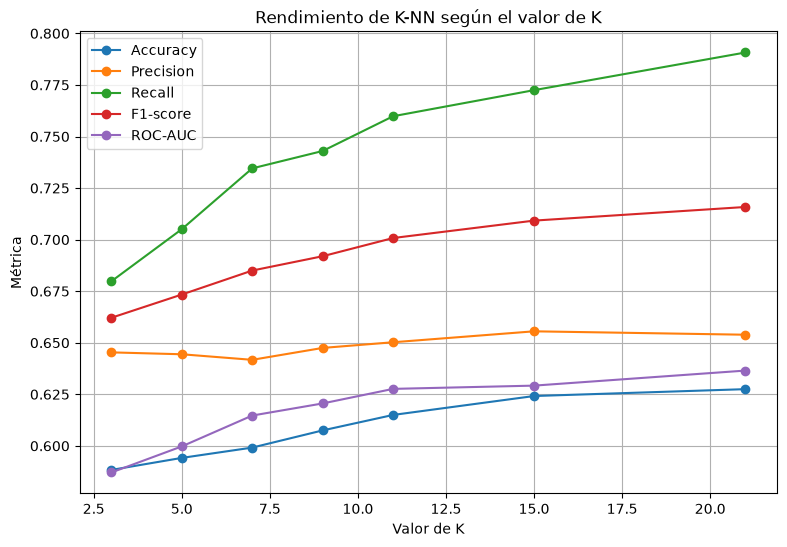

In [41]:
# Visualiza el comportamiento de las métricas según el valor de K
plt.figure(figsize=(9, 6))

plt.plot(resultados_knn["K"], resultados_knn["Accuracy"], marker="o", label="Accuracy")
plt.plot(resultados_knn["K"], resultados_knn["Precision"], marker="o", label="Precision")
plt.plot(resultados_knn["K"], resultados_knn["Recall"], marker="o", label="Recall")
plt.plot(resultados_knn["K"], resultados_knn["F1-score"], marker="o", label="F1-score")
plt.plot(resultados_knn["K"], resultados_knn["ROC-AUC"], marker="o", label="ROC-AUC")

plt.xlabel("Valor de K")
plt.ylabel("Métrica")
plt.title("Rendimiento de K-NN según el valor de K")
plt.legend()
plt.grid()

plt.show()

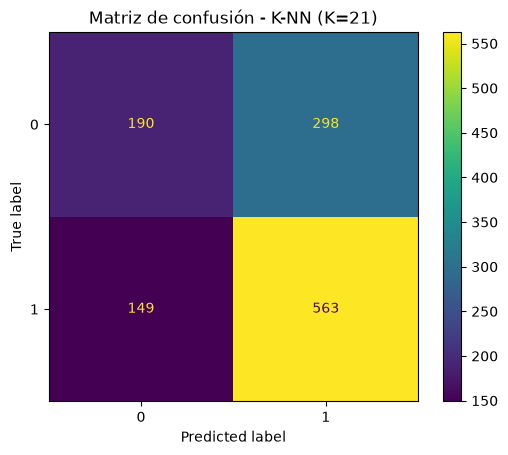

In [42]:
# Construye el modelo K-NN con K = 21
modelo_knn_final = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("modelo", KNeighborsClassifier(n_neighbors=21))
])

# Entrena el modelo
modelo_knn_final.fit(X_train_clas, y_train_clas)

# Genera las predicciones
y_pred_knn_final = modelo_knn_final.predict(X_test_clas)

# Calcula la matriz de confusión
matriz_confusion_knn = confusion_matrix(y_test_clas, y_pred_knn_final)

# Muestra la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion_knn)
disp.plot()

plt.title("Matriz de confusión - K-NN (K=21)")
plt.show()

# 6. Árbol de Decisión

En esta sección se construye un modelo de Árbol de Decisión para clasificar si un cliente realizará una compra o no a partir de sus características.

In [43]:
from sklearn.tree import DecisionTreeClassifier

# Combina el preprocesamiento con el modelo de Árbol de Decisión
modelo_arbol = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("modelo", DecisionTreeClassifier(random_state=42))
])

In [44]:
# Entrena el modelo utilizando los datos de entrenamiento
modelo_arbol.fit(X_train_clas, y_train_clas)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['cliente_edad','web_visitas_mes','publicidad_inversion', 'comportamiento_usuario','tipo_visitante_lag']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [45]:
# Genera las predicciones sobre los datos de prueba
y_pred_arbol = modelo_arbol.predict(X_test_clas)

In [46]:
# Obtiene la probabilidad estimada de compra
probabilidades_arbol = modelo_arbol.predict_proba(X_test_clas)[:, 1]

In [47]:
# Calcula las métricas de evaluación del modelo
accuracy_arbol = accuracy_score(y_test_clas, y_pred_arbol)
precision_arbol = precision_score(y_test_clas, y_pred_arbol)
recall_arbol = recall_score(y_test_clas, y_pred_arbol)
f1_arbol = f1_score(y_test_clas, y_pred_arbol)
roc_auc_arbol = roc_auc_score(y_test_clas, probabilidades_arbol)

print("Accuracy:", accuracy_arbol)
print("Precision:", precision_arbol)
print("Recall:", recall_arbol)
print("F1-score:", f1_arbol)
print("ROC-AUC:", roc_auc_arbol)

Accuracy: 0.5433333333333333
Precision: 0.6164772727272727
Recall: 0.6095505617977528
F1-score: 0.6129943502824858
ROC-AUC: 0.5281359366365813


In [48]:
# Genera las predicciones sobre los datos de entrenamiento
y_pred_arbol_train = modelo_arbol.predict(X_train_clas)

# Calcula el rendimiento del modelo en entrenamiento
accuracy_arbol_train = accuracy_score(y_train_clas, y_pred_arbol_train)
f1_arbol_train = f1_score(y_train_clas, y_pred_arbol_train)

print("Accuracy en entrenamiento:", accuracy_arbol_train)
print("F1-score en entrenamiento:", f1_arbol_train)

print("Accuracy en prueba:", accuracy_arbol)
print("F1-score en prueba:", f1_arbol)

Accuracy en entrenamiento: 0.9997916666666666
F1-score en entrenamiento: 0.9998244073748902
Accuracy en prueba: 0.5433333333333333
F1-score en prueba: 0.6129943502824858


In [49]:
# Crea un Árbol de Decisión con profundidad limitada
modelo_arbol_controlado = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("modelo", DecisionTreeClassifier(max_depth=5, random_state=42))
])

In [50]:
# Entrena el árbol con profundidad limitada
modelo_arbol_controlado.fit(X_train_clas, y_train_clas)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['cliente_edad','web_visitas_mes','publicidad_inversion', 'comportamiento_usuario','tipo_visitante_lag']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [51]:
# Genera las predicciones sobre los datos de prueba
y_pred_arbol_controlado = modelo_arbol_controlado.predict(X_test_clas)

# Obtiene las probabilidades de compra
probabilidades_arbol_controlado = modelo_arbol_controlado.predict_proba(X_test_clas)[:, 1]

In [52]:
# Calcula las métricas del árbol controlado
accuracy_arbol_controlado = accuracy_score(y_test_clas, y_pred_arbol_controlado)
precision_arbol_controlado = precision_score(y_test_clas, y_pred_arbol_controlado)
recall_arbol_controlado = recall_score(y_test_clas, y_pred_arbol_controlado)
f1_arbol_controlado = f1_score(y_test_clas, y_pred_arbol_controlado)
roc_auc_arbol_controlado = roc_auc_score(y_test_clas, probabilidades_arbol_controlado)

print("Accuracy:", accuracy_arbol_controlado)
print("Precision:", precision_arbol_controlado)
print("Recall:", recall_arbol_controlado)
print("F1-score:", f1_arbol_controlado)
print("ROC-AUC:", roc_auc_arbol_controlado)

Accuracy: 0.6466666666666666
Precision: 0.6548387096774193
Recall: 0.8553370786516854
F1-score: 0.7417783191230207
ROC-AUC: 0.662747225547983


In [53]:
# Genera las predicciones del árbol controlado sobre los datos de entrenamiento
y_pred_arbol_controlado_train = modelo_arbol_controlado.predict(X_train_clas)

# Calcula el rendimiento del árbol controlado en entrenamiento
accuracy_arbol_controlado_train = accuracy_score(
    y_train_clas,
    y_pred_arbol_controlado_train
)

f1_arbol_controlado_train = f1_score(
    y_train_clas,
    y_pred_arbol_controlado_train
)

print("Accuracy en entrenamiento:", accuracy_arbol_controlado_train)
print("F1-score en entrenamiento:", f1_arbol_controlado_train)

print("Accuracy en prueba:", accuracy_arbol_controlado)
print("F1-score en prueba:", f1_arbol_controlado)

Accuracy en entrenamiento: 0.6710416666666666
F1-score en entrenamiento: 0.7605035643864705
Accuracy en prueba: 0.6466666666666666
F1-score en prueba: 0.7417783191230207


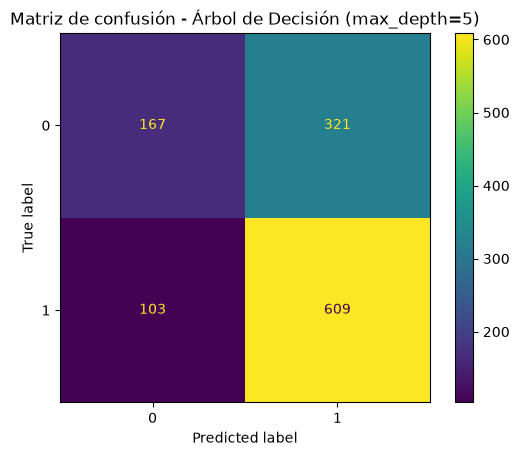

In [54]:
# Calcula la matriz de confusión del árbol controlado
matriz_confusion_arbol = confusion_matrix(
    y_test_clas,
    y_pred_arbol_controlado
)

# Muestra la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_arbol
)

disp.plot()

plt.title("Matriz de confusión - Árbol de Decisión (max_depth=5)")
plt.show()

# 7. Evaluación y comparación de modelos

En esta sección se comparan los resultados obtenidos por los modelos implementados y se analizan sus métricas de desempeño.

In [55]:
# Organiza los resultados de los modelos de clasificación
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "K-NN (K=21)",
        "Árbol de Decisión",
        "Árbol de Decisión (max_depth=5)"
    ],
    "Accuracy": [
        accuracy,
        resultados_knn.loc[resultados_knn["K"] == 21, "Accuracy"].iloc[0],
        accuracy_arbol,
        accuracy_arbol_controlado
    ],
    "Precision": [
        precision,
        resultados_knn.loc[resultados_knn["K"] == 21, "Precision"].iloc[0],
        precision_arbol,
        precision_arbol_controlado
    ],
    "Recall": [
        recall,
        resultados_knn.loc[resultados_knn["K"] == 21, "Recall"].iloc[0],
        recall_arbol,
        recall_arbol_controlado
    ],
    "F1-score": [
        f1,
        resultados_knn.loc[resultados_knn["K"] == 21, "F1-score"].iloc[0],
        f1_arbol,
        f1_arbol_controlado
    ],
    "ROC-AUC": [
        roc_auc,
        resultados_knn.loc[resultados_knn["K"] == 21, "ROC-AUC"].iloc[0],
        roc_auc_arbol,
        roc_auc_arbol_controlado
    ]
})

comparacion_modelos

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión Logística,0.636667,0.649028,0.844101,0.733822,0.659151
1,K-NN (K=21),0.627500,0.653891,0.790730,0.715830,0.636504
2,Árbol de Decisión,0.543333,0.616477,0.609551,0.612994,0.528136
3,Árbol de Decisión (max_depth=5),0.646667,0.654839,0.855337,0.741778,0.662747


In [56]:
from sklearn.model_selection import GridSearchCV

# Define los valores de K que serán evaluados mediante validación cruzada
parametros_knn = {
    "modelo__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "modelo__weights": ["uniform", "distance"]
}

# Configura la búsqueda de hiperparámetros
grid_knn = GridSearchCV(
    modelo_knn,
    parametros_knn,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Realiza la búsqueda utilizando únicamente los datos de entrenamiento
grid_knn.fit(X_train_clas, y_train_clas)

print("Mejores parámetros K-NN:", grid_knn.best_params_)
print("Mejor F1 de validación cruzada:", grid_knn.best_score_)

Mejores parámetros K-NN: {'modelo__n_neighbors': 21, 'modelo__weights': 'uniform'}
Mejor F1 de validación cruzada: 0.7257854984079417


In [57]:
# Define los valores de profundidad y tamaño mínimo de las particiones
parametros_arbol = {
    "modelo__max_depth": [3, 5, 7, 9, None],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 5]
}

# Configura la búsqueda de hiperparámetros
grid_arbol = GridSearchCV(
    modelo_arbol,
    parametros_arbol,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Realiza la búsqueda utilizando únicamente los datos de entrenamiento
grid_arbol.fit(X_train_clas, y_train_clas)

print("Mejores parámetros Árbol:", grid_arbol.best_params_)
print("Mejor F1 de validación cruzada:", grid_arbol.best_score_)

Mejores parámetros Árbol: {'modelo__max_depth': 5, 'modelo__min_samples_leaf': 5, 'modelo__min_samples_split': 2}
Mejor F1 de validación cruzada: 0.7421105771058432


In [58]:
# Obtiene el mejor modelo K-NN encontrado mediante validación cruzada
mejor_knn = grid_knn.best_estimator_

# Genera las predicciones sobre los datos de prueba
y_pred_knn_grid = mejor_knn.predict(X_test_clas)

# Obtiene las probabilidades de compra
probabilidades_knn_grid = mejor_knn.predict_proba(X_test_clas)[:, 1]

# Calcula las métricas del modelo optimizado
accuracy_knn_grid = accuracy_score(y_test_clas, y_pred_knn_grid)
precision_knn_grid = precision_score(y_test_clas, y_pred_knn_grid)
recall_knn_grid = recall_score(y_test_clas, y_pred_knn_grid)
f1_knn_grid = f1_score(y_test_clas, y_pred_knn_grid)
roc_auc_knn_grid = roc_auc_score(y_test_clas, probabilidades_knn_grid)

print("Accuracy:", accuracy_knn_grid)
print("Precision:", precision_knn_grid)
print("Recall:", recall_knn_grid)
print("F1-score:", f1_knn_grid)
print("ROC-AUC:", roc_auc_knn_grid)

Accuracy: 0.6275
Precision: 0.6538908246225319
Recall: 0.7907303370786517
F1-score: 0.715829624920534
ROC-AUC: 0.6365036148461966


In [59]:
# Obtiene el mejor Árbol de Decisión encontrado mediante validación cruzada
mejor_arbol = grid_arbol.best_estimator_

# Genera las predicciones sobre los datos de prueba
y_pred_arbol_grid = mejor_arbol.predict(X_test_clas)

# Obtiene las probabilidades de compra
probabilidades_arbol_grid = mejor_arbol.predict_proba(X_test_clas)[:, 1]

# Calcula las métricas del modelo optimizado
accuracy_arbol_grid = accuracy_score(y_test_clas, y_pred_arbol_grid)
precision_arbol_grid = precision_score(y_test_clas, y_pred_arbol_grid)
recall_arbol_grid = recall_score(y_test_clas, y_pred_arbol_grid)
f1_arbol_grid = f1_score(y_test_clas, y_pred_arbol_grid)
roc_auc_arbol_grid = roc_auc_score(y_test_clas, probabilidades_arbol_grid)

print("Accuracy:", accuracy_arbol_grid)
print("Precision:", precision_arbol_grid)
print("Recall:", recall_arbol_grid)
print("F1-score:", f1_arbol_grid)
print("ROC-AUC:", roc_auc_arbol_grid)

Accuracy: 0.645
Precision: 0.6547619047619048
Recall: 0.8497191011235955
F1-score: 0.7396088019559902
ROC-AUC: 0.6629227873457358


In [60]:
# Construye la comparación final de los modelos de clasificación
comparacion_final = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "K-NN optimizado",
        "Árbol de Decisión optimizado"
    ],
    "Accuracy": [
        accuracy,
        accuracy_knn_grid,
        accuracy_arbol_grid
    ],
    "Precision": [
        precision,
        precision_knn_grid,
        precision_arbol_grid
    ],
    "Recall": [
        recall,
        recall_knn_grid,
        recall_arbol_grid
    ],
    "F1-score": [
        f1,
        f1_knn_grid,
        f1_arbol_grid
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_knn_grid,
        roc_auc_arbol_grid
    ]
})

comparacion_final

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión Logística,0.636667,0.649028,0.844101,0.733822,0.659151
1,K-NN optimizado,0.627500,0.653891,0.790730,0.715830,0.636504
2,Árbol de Decisión optimizado,0.645000,0.654762,0.849719,0.739609,0.662923


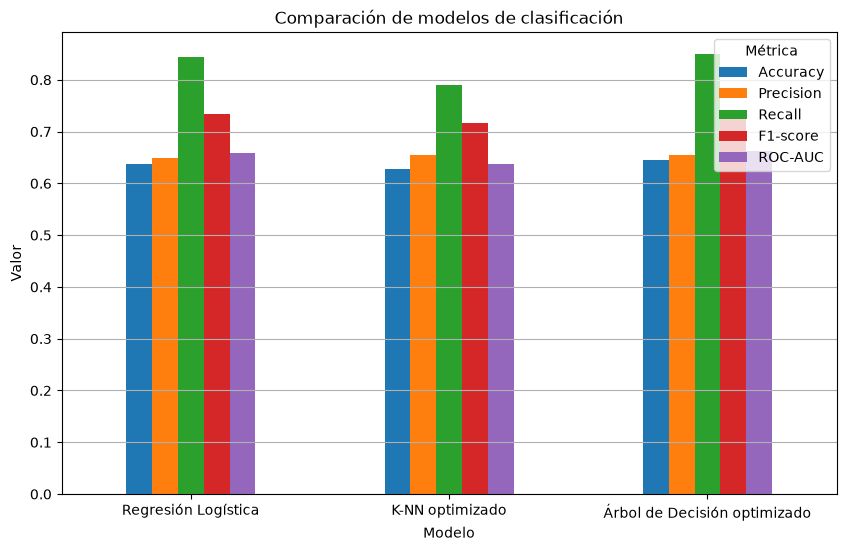

In [61]:
# Visualiza las métricas de los modelos de clasificación
metricas = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

comparacion_final.set_index("Modelo")[metricas].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Valor")
plt.xlabel("Modelo")
plt.title("Comparación de modelos de clasificación")
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.grid(axis="y")

plt.show()

# 8. Conclusiones

En el desarrollo del ejercicio se implementaron modelos de Regresión Lineal, Regresión Logística, K-Nearest Neighbors y Árbol de Decisión utilizando un pipeline de preparación y transformación de los datos.

La Regresión Lineal permitió realizar la predicción del valor mensual de las ventas. Sin embargo, obtuvo un R² de 0,0004, lo que evidencia una capacidad limitada para explicar la variabilidad de las ventas con las variables utilizadas. Además, el RMSE fue de aproximadamente $496.460, mostrando una diferencia considerable entre algunos valores reales y las predicciones.

Para la clasificación de compra o no compra se implementaron Regresión Logística, K-NN y Árbol de Decisión. La Regresión Logística obtuvo un Accuracy de 63,67 %, Recall de 84,41 %, F1-score de 73,38 % y ROC-AUC de 65,92 %. También se analizaron diferentes umbrales, observando que el cambio del umbral modifica el equilibrio entre Precision y Recall.

En K-NN se evaluaron diferentes valores de K. La validación mediante GridSearch confirmó K=21 con pesos uniformes como configuración seleccionada. El modelo obtuvo un F1-score de 71,90 % y un ROC-AUC de 64,27 % sobre los datos de prueba.

En el Árbol de Decisión se evidenció inicialmente un sobreajuste, debido a que el modelo alcanzó valores cercanos al 100 % en los datos de entrenamiento mientras presentaba un rendimiento considerablemente menor en los datos de prueba. Al limitar la profundidad del árbol y posteriormente utilizar GridSearch con validación cruzada, se redujo la diferencia entre entrenamiento y prueba y se obtuvo un F1-score de 73,96 % y un ROC-AUC de 66,26 %.

Finalmente, el ejercicio permitió aplicar técnicas de imputación, escalamiento, codificación de variables categóricas, validación cruzada y selección de hiperparámetros. Los resultados muestran que el desempeño de un modelo depende tanto del algoritmo como de la preparación de los datos, la selección de variables y el ajuste de sus parámetros.